# Lab01 - Regresión lineal simple desde cero

En este notebook implemento una regresión lineal simple paso a paso,
con el objetivo de entender cómo funciona el modelo internamente.

## Etapa 0 - Entender el problema

En este laboratorio vamos a trabajar con un caso simple de regresión lineal.

Queremos predecir el puntaje de una prueba a partir de la cantidad de horas de estudio.

- Variable de entrada (x): horas de estudio
- Variable objetivo (y): puntaje en la prueba

La idea es analizar si existe una relación aproximada entre ambas variables y usar una recta para modelarla.

## Etapa 1 - Definir un dataset propio

Vamos a trabajar con un ejemplo simple y ficticio.

Este dataset representa la relación entre horas de estudio y puntaje obtenido.

Queremos modelar la relación entre:
- horas de estudio
- puntaje obtenido en una prueba

Usaremos un conjunto pequeño de datos para entender con claridad cómo funciona una regresión lineal simple.

### Dataset propuesto

<table style="margin-left: 0; margin-right: auto;">
  <tr>
    <th style="text-align:left; padding-right:20px;">Horas de estudio</th>
    <th style="text-align:left;">Puntaje</th>
  </tr>
  <tr><td>1</td><td>52</td></tr>
  <tr><td>2</td><td>57</td></tr>
  <tr><td>3</td><td>63</td></tr>
  <tr><td>4</td><td>68</td></tr>
  <tr><td>5</td><td>74</td></tr>
</table>

Cada fila representa un ejemplo de entrenamiento: una cantidad de horas estudiadas y el puntaje correspondiente.

In [1]:
#Horas de estudio (variable de entrada)
x_train = [1, 2, 3, 4, 5]
#Puntaje obtenido (variable objetivo)
y_train = [52, 57, 63, 68, 74]
print(f"x_train = {x_train}")
print(f"y_train = {y_train}")

x_train = [1, 2, 3, 4, 5]
y_train = [52, 57, 63, 68, 74]


### Inspección inicial del dataset

Antes de seguir, conviene verificar cuántos ejemplos tenemos en el conjunto de datos.

También vamos a guardar esa cantidad en la variable `m`, que suele representar el número de ejemplos de entrenamiento.

In [2]:
m = len(x_train)
print (f"Cantidad de ejemplos de entrenamiento : {m}")

Cantidad de ejemplos de entrenamiento : 5


In [3]:
for i in range(m):
    print(f"Ejemplo {i}: x = {x_train[i]}, y = {y_train[i]}")


Ejemplo 0: x = 1, y = 52
Ejemplo 1: x = 2, y = 57
Ejemplo 2: x = 3, y = 63
Ejemplo 3: x = 4, y = 68
Ejemplo 4: x = 5, y = 74


## Etapa 2 - Visualización inicial

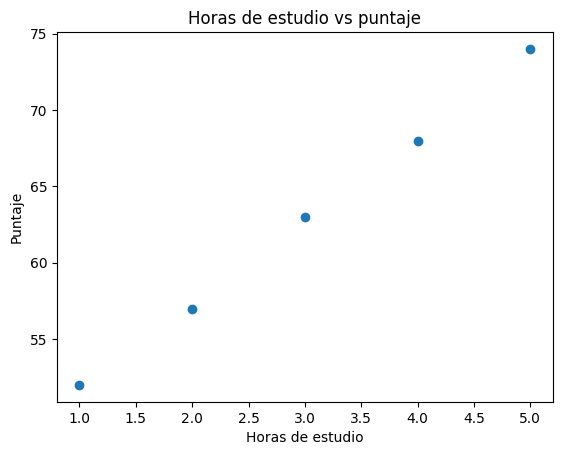

In [4]:
import matplotlib.pyplot as plt
plt.scatter(x_train,y_train)
plt.title("Horas de estudio vs puntaje")
plt.xlabel("Horas de estudio")
plt.ylabel("Puntaje")
plt.show()

La idea visual importante es esta:

cuando aumentan las horas de estudio
también aumenta el puntaje

Eso sugiere una relación positiva entre ambas variables.

No prueba nada todavía, pero sí da una primera señal de que una recta podría tener sentido.

## Etapa 3 - Modelo lineal

Para modelar la relación entre horas de estudio y puntaje, vamos a usar una recta.

La forma general del modelo es:

$f_{w,b}(x) = w \cdot x + b$

donde:
- x es la variable de entrada
- w es la pendiente de la recta
- b es la ordenada al origen

La salida del modelo será un puntaje estimado para cada cantidad de horas de estudio.

### Nuestro ejemplo

*x* es la variable de entrada (horas de estudio).

*w* es el parámetro que indica cuánto cambia la predicción cuando cambia x.

Intuitivamente:

si w es grande, el puntaje sube más rápido al aumentar las horas

si w es chico, sube más lento

si fuera negativo, bajaría

b es el valor que daría la recta cuando x = 0.

No siempre tiene interpretación realista fuerte, pero matemáticamente forma parte del modelo.

*$f_{w,b}(x)$* es la predicción del modelo para un valor x, usando los parámetros w y b.

In [5]:
def f_wb (x,w,b): 
    return w * x + b

### Veamos un ejemplo de predicción

In [6]:
w = 5.5
b = 46.3

x_values = x_train
y_hat = []

for x in x_values:
    y_hat.append(f_wb (x, w, b))

print(y_hat)

[51.8, 57.3, 62.8, 68.3, 73.8]


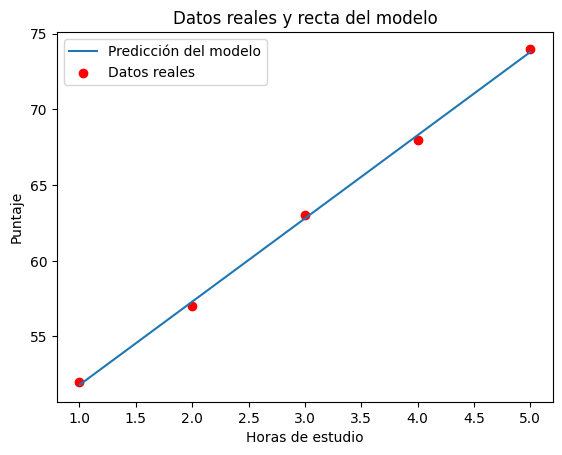

In [7]:
plt.plot(x_values, y_hat, label="Predicción del modelo")
plt.scatter(x_train,y_train, c='r', label="Datos reales")
plt.legend()
plt.title("Datos reales y recta del modelo")
plt.xlabel("Horas de estudio")
plt.ylabel("Puntaje")
plt.show()

plot no siempre dibuja “una recta”; dibuja una línea uniendo puntos. En este caso se ve como recta porque las predicciones vienen de un modelo lineal.

La función de coste de regresión lineal simple es:

$
J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2
$

donde:

$f_{w,b}(x^{(i)}) = wx^{(i)} + b$

## Etapa 4 - Ajuste automático de los parámetros con descenso de gradiente

Hasta ahora elegimos valores de `w` y `b` manualmente y calculamos qué tan bueno era el modelo usando la función de coste.

La idea ahora es que el programa pueda mejorar esos valores automáticamente.

Recordemos que el modelo lineal es:

$f_{w,b}(x) = wx + b$

y que la función de coste mide el error promedio del modelo:

$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} \left(f_{w,b}(x^{(i)}) - y^{(i)}\right)^2$

El objetivo del descenso de gradiente es encontrar valores de `w` y `b` que hagan que `J(w,b)` sea lo más chica posible.

### Idea intuitiva

Podemos imaginar la función de coste como una superficie con subidas y bajadas.  
El descenso de gradiente intenta bajar por esa superficie dando pequeños pasos en la dirección donde el coste disminuye.

En cada iteración, el algoritmo:

1. calcula qué tan mal está prediciendo el modelo;
2. calcula hacia dónde deberían moverse `w` y `b`;
3. actualiza `w` y `b`;
4. vuelve a calcular el coste;
5. repite el proceso muchas veces.

### Actualización de los parámetros

Los parámetros se actualizan así:

$
w = w - \alpha \frac{\partial J(w,b)}{\partial w}
$

$
b = b - \alpha \frac{\partial J(w,b)}{\partial b}
$

Donde:

- `alpha` es la tasa de aprendizaje;
- la derivada respecto de `w` indica cómo debería cambiar la pendiente;
- la derivada respecto de `b` indica cómo debería cambiar la ordenada al origen.

### Tasa de aprendizaje

La tasa de aprendizaje, `alpha`, controla el tamaño de los pasos.

Si `alpha` es muy chica, el algoritmo aprende muy lento.  
Si `alpha` es muy grande, puede pasarse de largo y no converger.

En este laboratorio vamos a usar valores chicos para observar cómo el coste va bajando paso a paso.


In [8]:
def Jwb (x,y,w,b): 
    suma = 0
    m = len(x)

    for i in range(m):
        prediccion=f_wb(x[i],w,b)
        diferencia=prediccion-y[i]
        suma = suma + (diferencia)**2
        #print (f"Predicción : {prediccion}")
        #print (f"Valor real : {y[i]}")
        #print (f"Diferencia : {diferencia}")
        
    res=1/(2*m)*suma
    #print (f"valor funcion de coste para w = {w} y b = {b} es {res}")
    return 1/(2*m)*suma  
    

In [9]:
m = len(x_train)
#w=5
#b=40
#Usamos valores seteados en etapa 3

coste=Jwb(x_train, y_train, w, b)
print (f"Coste = {coste}")

Coste = 0.03


## Etapa 5 - Descenso de gradiente

### Derivada parcial respecto de `w`

La derivada respecto de `w` se calcula como:

$
\frac{\partial J(w,b)}{\partial w} =
\frac{1}{m} \sum_{i=0}^{m-1}
\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)x^{(i)}
$

Esta derivada nos dice cuánto cambia el coste cuando modificamos la pendiente `w`.

In [10]:
#derivada parcial en funcion de w
def dJw_wb (x,y,w,b):
    m = len (x)
    suma = 0
    for i in range(m):
        suma = suma + (w*x[i]+b-y[i])*x[i]
    return suma/m

### Derivada parcial respecto de `b`

La derivada respecto de `b` se calcula como:

$
\frac{\partial J(w,b)}{\partial b} =
\frac{1}{m} \sum_{i=0}^{m-1}
\left(f_{w,b}(x^{(i)}) - y^{(i)}\right)
$

Esta derivada nos dice cuánto cambia el coste cuando modificamos la ordenada al origen `b`.

In [11]:
#derivada parcial en funcion de b
def dJb_wb (x,y,w,b):
    m = len (x)
    suma = 0
    for i in range(m):
        suma = suma + (w*x[i] + b - y[i])
    return suma/m

In [12]:
#actualizacion de w para algoritmo de descenso de gradiente
def update_w (alfa,x,y,w,b):
    return w - alfa*(dJw_wb (x,y,w,b))

#actualizacion de b para algoritmo de descenso de gradiente
def update_b (alfa,x,y,w,b):
    return b - alfa*(dJb_wb (x,y,w,b))

In [13]:
#algoritmo de gradiente descendente

def gradiente_descendente (alfa,x,y,w,b,it,tope):
    coste = 3
    iteraciones = 0 
    coste_anterior = 0
    historial_w = []
    historial_b = []
    historial_coste = []
    historial_w.append(w)
    historial_b.append(b)
    historial_coste.append(Jwb(x, y, w, b))
    while coste > tope and iteraciones < it:
        iteraciones = iteraciones + 1
        w_tmp = w
        w = update_w (alfa,x,y,w_tmp,b)
        b = update_b (alfa,x,y,w_tmp,b)
        coste_anterior = coste
        coste = Jwb (x,y,w,b)
        
        historial_w.append(w)
        historial_b.append(b)
        historial_coste.append(coste)
        
        if abs(coste_anterior - coste) < 0.0000001:
            print("El coste ya no cambia de forma significativa. Corto el algoritmo.")
            break
       
    print (f"Iteracion: {iteraciones} - w: {w} - b: {b}")
    return w, b, historial_w, historial_b, historial_coste       

## Etapa 6 - Entrenamiento

In [14]:
#Prueba de aprendizaje...
alfa = 0.1
w = 15
b = 4
x = x_train
y = y_train
w,b, historial_w, historial_b, historial_coste = gradiente_descendente (alfa,x,y,w,b,10000,0.01)

El coste ya no cambia de forma significativa. Corto el algoritmo.
Iteracion: 523 - w: 5.5015501898171495 - b: 46.294403322887526


## Resultado del entrenamiento

Luego de aplicar descenso de gradiente, el modelo encontró valores de `w` y `b` que reducen la función de coste.

Este modelo aproxima bastante bien la relación entre horas de estudio y puntaje para este dataset pequeño.



In [15]:
print(f"w aprendido = {w}")
print(f"b aprendido = {b}")
print(f"Coste final = {historial_coste[-1]}")

w aprendido = 5.5015501898171495
b aprendido = 46.294403322887526
Coste final = 0.030002850648322033


## Etapa 7 - Visualización del aprendizaje

### Interpretación de la gráfica `w` vs función de coste

En esta gráfica se observa cómo cambia el valor de la función de coste a medida que el algoritmo de descenso de gradiente va actualizando el parámetro `w`.

Cada punto representa una iteración del algoritmo.

La separación entre puntos muestra cuánto cambia el valor de `w` y de la función de coste en cada paso. En general, al comienzo los cambios pueden ser más grandes porque el modelo está más lejos del mínimo. A medida que el algoritmo se acerca a una mejor solución, los puntos quedan más próximos entre sí y el coste deja de disminuir de forma significativa.

Por eso, esta gráfica debe interpretarse como una vista parcial del proceso: muestra cómo evoluciona el coste en relación con `w`, pero no permite ver toda la superficie de la función de coste.

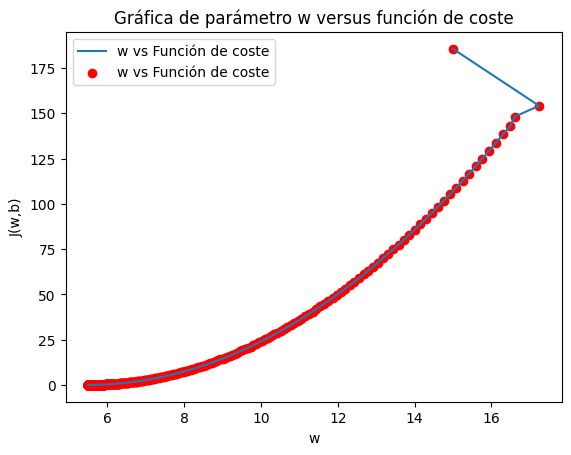

In [16]:
plt.plot(historial_w, historial_coste, label="w vs Función de coste")
plt.scatter(historial_w, historial_coste, c='r', label="w vs Función de coste")
plt.legend()
plt.title("Gráfica de parámetro w versus función de coste")
plt.xlabel("w")
plt.ylabel("J(w,b)")
plt.show()

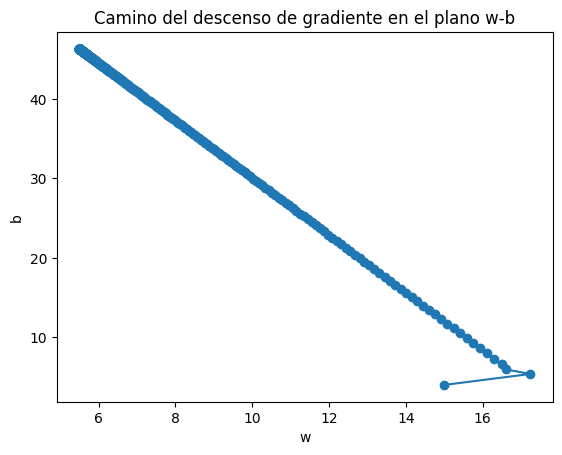

In [17]:
plt.plot(historial_w, historial_b, marker="o")
plt.xlabel("w")
plt.ylabel("b")
plt.title("Camino del descenso de gradiente en el plano w-b")
plt.show()

## Explicación de la gráfica de contornos 2D con flechas

Esta gráfica muestra la función de coste `J(w,b)` vista desde arriba, como si miráramos la superficie 3D desde una vista superior.

En lugar de mostrar la altura de la superficie en 3D, se usan curvas de nivel o contornos.

Cada contorno representa combinaciones de `w` y `b` que tienen un valor parecido de la función de coste.

En la gráfica:

- el eje `x` representa valores posibles de `w`;
- el eje `y` representa valores posibles de `b`;
- las curvas representan niveles de la función de coste `J(w,b)`;
- el camino con puntos muestra cómo se movieron `w` y `b` durante el descenso de gradiente;
- las flechas muestran el sentido del movimiento;
- el punto inicial muestra desde dónde arrancó el algoritmo;
- el punto final muestra los parámetros aprendidos.

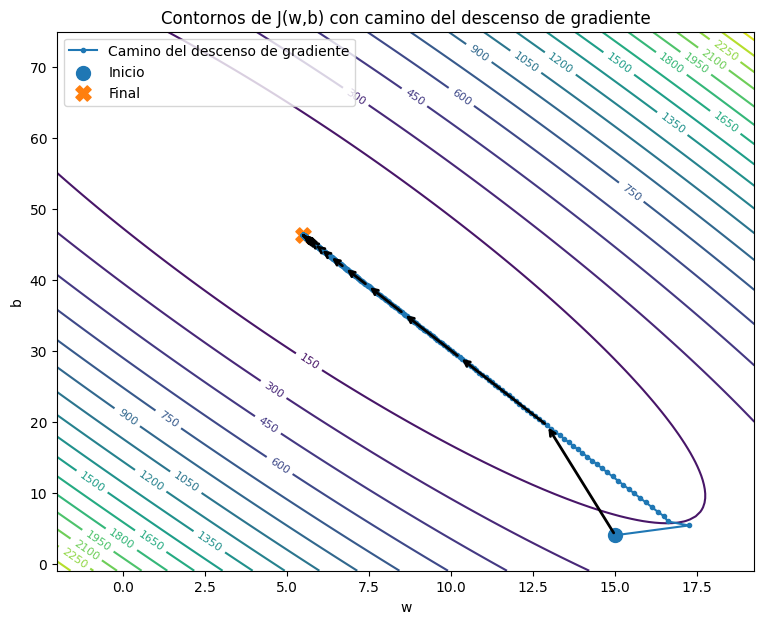

In [18]:
import numpy as np
import matplotlib.pyplot as plt

plt.close("all")

w_camino = np.array(historial_w)
b_camino = np.array(historial_b)

w_min = min(w_camino.min(), 0) - 2
w_max = max(w_camino.max(), 12) + 2

b_min = min(b_camino.min(), 20) - 5
b_max = max(b_camino.max(), 70) + 5

w_vals = np.linspace(w_min, w_max, 120)
b_vals = np.linspace(b_min, b_max, 120)

W, B = np.meshgrid(w_vals, b_vals)

J_vals = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = Jwb(x_train, y_train, W[i, j], B[i, j])

fig, ax = plt.subplots(figsize=(9, 7))

# Curvas de nivel: los "óvalos"
contornos = ax.contour(W, B, J_vals, levels=20)
ax.clabel(contornos, inline=True, fontsize=8)

# Camino del descenso de gradiente
ax.plot(
    w_camino,
    b_camino,
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Camino del descenso de gradiente"
)

# Flechas de dirección
paso = max(1, len(w_camino) // 20)

for k in range(0, len(w_camino) - paso, paso):
    ax.annotate(
        "",
        xy=(w_camino[k + paso], b_camino[k + paso]),
        xytext=(w_camino[k], b_camino[k]),
        arrowprops=dict(arrowstyle="->", linewidth=2)
    )

# Inicio y final
ax.scatter(w_camino[0], b_camino[0], s=100, marker="o", label="Inicio")
ax.scatter(w_camino[-1], b_camino[-1], s=120, marker="X", label="Final")

ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_title("Contornos de J(w,b) con camino del descenso de gradiente")
ax.legend()

plt.show()

Si el descenso de gradiente está funcionando bien, el camino debería avanzar hacia zonas de menor coste.

El punto final representa los valores de `w` y `b` obtenidos luego del entrenamiento.

Esta gráfica ayuda a entender el descenso de gradiente porque muestra el recorrido de los parámetros sobre el mapa de la función de coste.

## Conclusión

En este laboratorio implementé regresión lineal desde cero.

Esto permitió entender:
- cómo se calcula una predicción;
- cómo se mide el coste;
- cómo el descenso de gradiente ajusta los parámetros;
- cómo el modelo se acerca a una solución de bajo coste.

Este enfoque permite comprender el funcionamiento interno del modelo,
más allá del uso de librerías como scikit-learn.

## Limitaciones

Este ejemplo usa un dataset pequeño y ficticio. El objetivo no es construir un modelo predictivo real, sino entender el funcionamiento interno de la regresión lineal y del descenso de gradiente.